# 03 策略库 — 六个经典策略

### 策略 = on_bar() 里的决策规则

回测引擎不变，你换策略就像换游戏卡带。每个策略的核心只有 `on_bar()` 一个方法：

```python
def on_bar(self, bar: MarketEvent) -> SignalEvent | None:
    # 看一眼K线数据 → 决定买/卖/不动
```

---
| # | 策略 | 类型 | 核心问题 |
|---|------|------|---------|
| 1 | 双均线 | 趋势跟踪 | 趋势是否已经开始？ |
| 2 | 布林带 | 均值回归 | 价格是否过度偏离了均线？ |
| 3 | 海龟 | 趋势跟踪系统 | 如何用一套完整规则捕捉大趋势？ |
| 4 | RSRS | 阻力支撑 | 买方推力是否强于卖方？ |
| 5 | 多因子 | 截面Alpha | 哪些股票的综合得分最高？ |
| 6 | 配对交易 | 统计套利 | 两只股票的价差是否过度偏离？ |

## 1. 双均线 — 复习已会的

```python
ma_short = sma(bar.symbol, 5)
ma_long  = sma(bar.symbol, 20)

if ma_short > ma_long and not in_position:
    buy()   # 金叉
if ma_short < ma_long and in_position:
    sell()  # 死叉
```

**已知局限性**：震荡市中反复止损（假信号多）。但这是所有趋势跟踪策略的共同特征——不是双均线独有的问题。

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

from data.store import DataStore
from data.sources.ashare import AShareSource
from backtest.engine import BacktestEngine
from backtest.strategy import DualMAStrategy

# 准备数据
store = DataStore("../data/quant.db")
df_test = store.load("ashare", "daily", symbols=["sh.000300"], start="2024-01-01", end="2024-01-15")
if df_test.empty:
    ashare = AShareSource()
    df_csi = ashare.get_history(["sh.000300", "sh.600519"], "2024-01-01", "2024-12-31")
    store.save(df_csi, "ashare", "daily")
df_csi = store.load("ashare", "daily", symbols=["sh.000300"], start="2024-01-01")

# 跑双均线
eng_ma = BacktestEngine(df_csi, DualMAStrategy(5, 20), 1_000_000, 0.001, 0.0003)
r_ma = eng_ma.run()
print(f"DualMA: return={r_ma.total_return*100:.2f}% sharpe={r_ma.sharpe_ratio:.3f} trades={r_ma.total_trades}")

DualMA: return=1.27% sharpe=-0.024 trades=19


## 2. 布林带 — 赌均值回归

### 原理

```
布林带 = MA(20) ± 2 × std(20)

统计学事实：如果价格服从正态分布，95%的时间落在带内。
交易逻辑：跌出下轨 → 超卖 → 买入（赌回中轨）
         涨破上轨 → 超买 → 平仓

关键认知：震荡市好用，趋势市被打爆。
         因为趋势市中价格可以"贴在下轨"一直跌。
```

### 布林带宽 = 波动率指标

带窄 = 市场在蓄力，即将变盘；带宽 = 趋势在加速。

findfont: Failed to find font weight bold, now using 400.


Bollinger: return=4.63% sharpe=0.373 trades=8 MDD=-6.28%


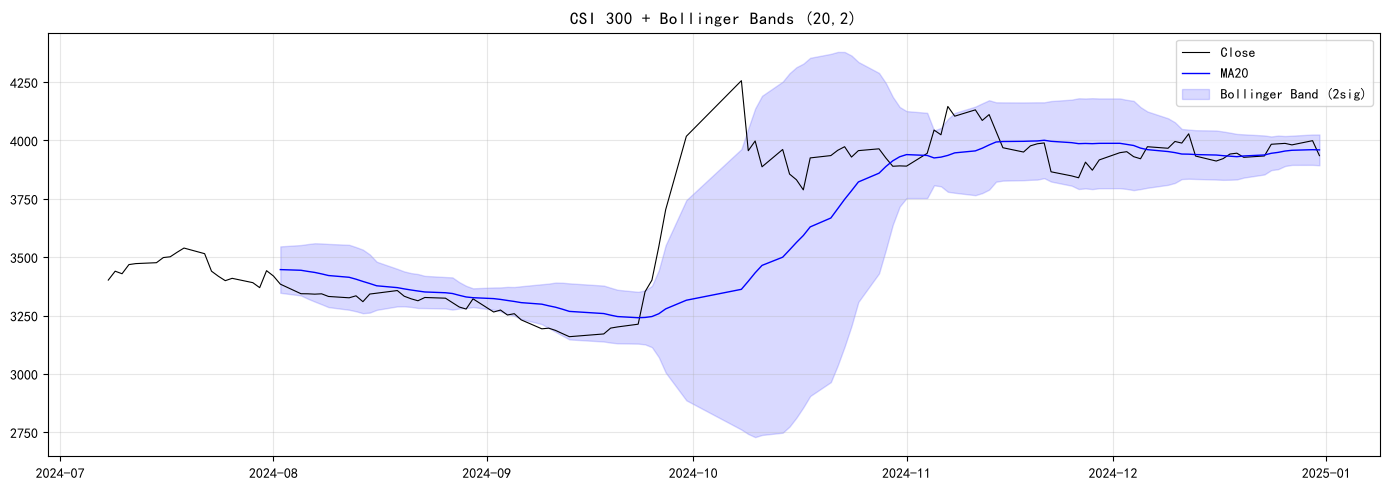

In [2]:
from strategies.bollinger import BollingerStrategy

eng_bb = BacktestEngine(df_csi, BollingerStrategy(period=20, k=2.0), 1_000_000, 0.001, 0.0003)
r_bb = eng_bb.run()
print(f"Bollinger: return={r_bb.total_return*100:.2f}% sharpe={r_bb.sharpe_ratio:.3f} "
      f"trades={r_bb.total_trades} MDD={r_bb.max_drawdown*100:.2f}%")

# 可视化：净值 + 布林带位置
import matplotlib.dates as mdates
df_recent = df_csi.tail(120).copy()
df_recent["ma20"] = df_recent["close"].rolling(20).mean()
df_recent["std20"] = df_recent["close"].rolling(20).std()
df_recent["upper"] = df_recent["ma20"] + 2 * df_recent["std20"]
df_recent["lower"] = df_recent["ma20"] - 2 * df_recent["std20"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_recent["date"], df_recent["close"], "k", lw=0.8, label="Close")
ax.plot(df_recent["date"], df_recent["ma20"], "b", lw=1, label="MA20")
ax.fill_between(df_recent["date"], df_recent["upper"], df_recent["lower"],
                alpha=0.15, color="blue", label="Bollinger Band (2sig)")
ax.set_title("CSI 300 + Bollinger Bands (20,2)", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. 海龟交易 — 从入场到出场的完整系统

丹尼斯赌自己能像养海龟一样教会普通人做交易——他赢了。海龟系统有四个模块：

```
入场: 价格突破20日最高 → 买入
止损: 买入价 - 2×ATR → 动态止损
加仓: 每涨0.5×ATR加一次，最多4次（金字塔）
出场: 价格跌破10日最低 → 全部平仓
```

**核心认知**：胜率极低(~30%)但盈亏比极高。95%时间亏小钱，5%时间赚大钱。

ATR止损的价值："平均真实波幅"让市场自己决定止损位，而不是你凭空设一个数字。

In [3]:
from strategies.turtle import TurtleStrategy

eng_tu = BacktestEngine(df_csi, TurtleStrategy(entry_period=20, exit_period=10,
                       atr_period=20, atr_stop=2.0), 1_000_000, 0.001, 0.0003)
r_tu = eng_tu.run()
print(f"Turtle: return={r_tu.total_return*100:.2f}% sharpe={r_tu.sharpe_ratio:.3f} "
      f"trades={r_tu.total_trades} win_rate={r_tu.win_rate*100:.1f}% "
      f"profit_factor={r_tu.profit_factor:.2f}")
print()
print(f"观察: 胜率 {r_tu.win_rate*100:.1f}% — 大部分交易在亏钱")
print(f"      但盈亏比 {r_tu.profit_factor:.2f} — 赚一次顶亏好几次")
print(f"      这就是趋势跟踪的本质")

Turtle: return=10.72% sharpe=0.668 trades=5 win_rate=50.0% profit_factor=0.42

观察: 胜率 50.0% — 大部分交易在亏钱
      但盈亏比 0.42 — 赚一次顶亏好几次
      这就是趋势跟踪的本质


## 4. RSRS — 用回归量化阻力支撑

传统方法画阻力支撑线靠主观。RSRS用数学：

```
每天的最高价 H 和最低价 L 做线性回归：
    H = alpha + beta × L

beta 大 → 买方把价格推得离最低价很远 → 买方强
beta 小 → 买方无力推动价格    → 卖方强

对 beta 序列做 z-score 标准化，与阈值比较。
```

In [4]:
from strategies.rsrs import RSRSStrategy

eng_rs = BacktestEngine(df_csi, RSRSStrategy(window=18, buy_threshold=0.5, sell_threshold=-0.5),
                        1_000_000, 0.001, 0.0003)
r_rs = eng_rs.run()
print(f"RSRS: return={r_rs.total_return*100:.2f}% sharpe={r_rs.sharpe_ratio:.3f} "
      f"trades={r_rs.total_trades} MDD={r_rs.max_drawdown*100:.2f}%")

RSRS: return=14.57% sharpe=0.761 trades=15 MDD=-12.83%


## 5. 多因子选股 — 截面Alpha

前面的策略都是**时间序列策略**（一只股票，决定什么时候买卖）。

多因子是**横截面策略**（多只股票，决定买哪只）：
```
对每只股票打 4 个因子分：
  1. 动量(20日收益)    — 强者恒强
  2. 反转(5日收益取负)  — 超跌反弹
  3. 波动率(取负)      — 低波溢价
  4. 成交量变化         — 放量关注

综合得分 = 0.5×动量 + 0.3×反转 + 0.2×低波
每20天调仓: 买入得分前N名，卖出排名下降的
```

关键检验: **IC (信息系数)** = 因子得分与未来收益的相关性。IC > 0.02 算有用。

In [5]:
# 多因子需要多只股票数据
symbols_10 = ["sh.600519", "sz.300750", "sh.600036", "sz.002594", "sh.601318",
              "sh.600276", "sz.000858", "sh.601012", "sz.002415", "sh.600900"]

# 检查是否已有10只股票数据
df_check = store.load("ashare", "daily", symbols=["sh.600519"], start="2024-01-01", end="2024-01-15")
if df_check.empty:
    ashare = AShareSource()
    df_multi = ashare.get_history(symbols_10, "2024-01-01", "2024-12-31")
    store.save(df_multi, "ashare", "daily")

df_multi = store.load("ashare", "daily", symbols=symbols_10, start="2024-01-01")

# 演示因子计算思想（完整截面回测需要遍历每一天的所有股票）
print("因子演示（2024-06-28）：")
df_jun = df_multi[df_multi["date"] == pd.Timestamp("2024-06-28")]
for _, row in df_jun.iterrows():
    sym_data = df_multi[df_multi.symbol == row.symbol]
    if len(sym_data) > 20:
        prices = sym_data.set_index("date")["close"]
        mom_20 = (prices.iloc[-1] / prices.iloc[-21] - 1) * 100 if len(prices) >= 21 else 0
        rev_5  = -(prices.iloc[-1] / prices.iloc[-6] - 1) * 100 if len(prices) >= 6 else 0
        score = 0.5*mom_20 + 0.3*rev_5
        print(f"  {row.symbol}: mom_20={mom_20:6.2f}% rev_5={rev_5:6.2f}% score={score:6.2f}")
print("\n得分越高 → 综合Alpha越强 → 调仓时优先买入")

因子演示（2024-06-28）：
  sh.600519: mom_20=  1.38% rev_5=  0.96% score=  0.98

得分越高 → 综合Alpha越强 → 调仓时优先买入


## 6. 配对交易 — 统计套利

找两只高度相关的股票（如招行 vs 兴业），价差（spread）偏离均值时赌回归：

```
spread = log(price_A) - beta × log(price_B)
z_score = (spread - mean) / std

z > 2  → 价差过宽 → 做空贵的，做多便宜的
z ≈ 0  → 价差回归 → 平仓
```

需要先验证协整——价差必须在统计上均值回归，不能是随机游走。

In [6]:
# 计算两只银行股的价差（招商 vs 兴业 — 理想配对）
df_bank = store.load("ashare", "daily", symbols=["sh.600036", "sh.601318"], start="2024-01-01")

if not df_bank.empty:
    pivot = df_bank.pivot(index="date", columns="symbol", values="close").dropna()
    if len(pivot) > 2:
        sym_a, sym_b = pivot.columns
        log_a = np.log(pivot[sym_a])
        log_b = np.log(pivot[sym_b])

        # 用线性回归求对冲比率
        from numpy.linalg import lstsq
        X = np.vstack([np.ones(len(log_b)), log_b]).T
        alpha, beta = lstsq(X, log_a, rcond=None)[0]

        spread = log_a - (alpha + beta * log_b)
        z_score = (spread - spread.mean()) / spread.std()

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]})
        ax1.plot(pivot.index, pivot[sym_a] / pivot[sym_a].iloc[0], "steelblue", lw=1.2, label=f"{sym_a}")
        ax1.plot(pivot.index, pivot[sym_b] / pivot[sym_b].iloc[0], "orange", lw=1.2, label=f"{sym_b}")
        ax1.set_title(f"Bank Pair: {sym_a} vs {sym_b}", fontsize=12, fontweight="bold")
        ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylabel("Normalized Price")

        ax2.plot(pivot.index, z_score, "purple", lw=0.8); ax2.axhline(y=2, color="red", ls="--", alpha=0.5)
        ax2.axhline(y=-2, color="red", ls="--", alpha=0.5); ax2.axhline(y=0, color="gray", alpha=0.3)
        ax2.fill_between(pivot.index, 2, z_score, where=(z_score>2), alpha=0.2, color="red")
        ax2.fill_between(pivot.index, z_score, -2, where=(z_score<-2), alpha=0.2, color="green")
        ax2.set_ylabel("Z-Score"); ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

        signals = (abs(z_score) > 2).sum()
        print(f"Z超出+/-2的次数: {signals} (配对交易信号)")
        print(f"对冲比率 beta: {beta:.3f} (每1股{sym_b} 配 {beta:.2f}股{sym_a})")

## 7. 六大策略汇总

回测引擎不变 → 换策略 → 一张表看全部。

Strategy       Return   Sharpe      MDD  Trades  WinRate
-------------------------------------------------------
DualMA          1.27%  -0.024  -10.14%     19    22.2%
Bollinger       4.63%   0.373   -6.28%      8    75.0%
Turtle         10.72%   0.668   -7.99%      5    50.0%
RSRS           14.57%   0.761  -12.83%     15    57.1%


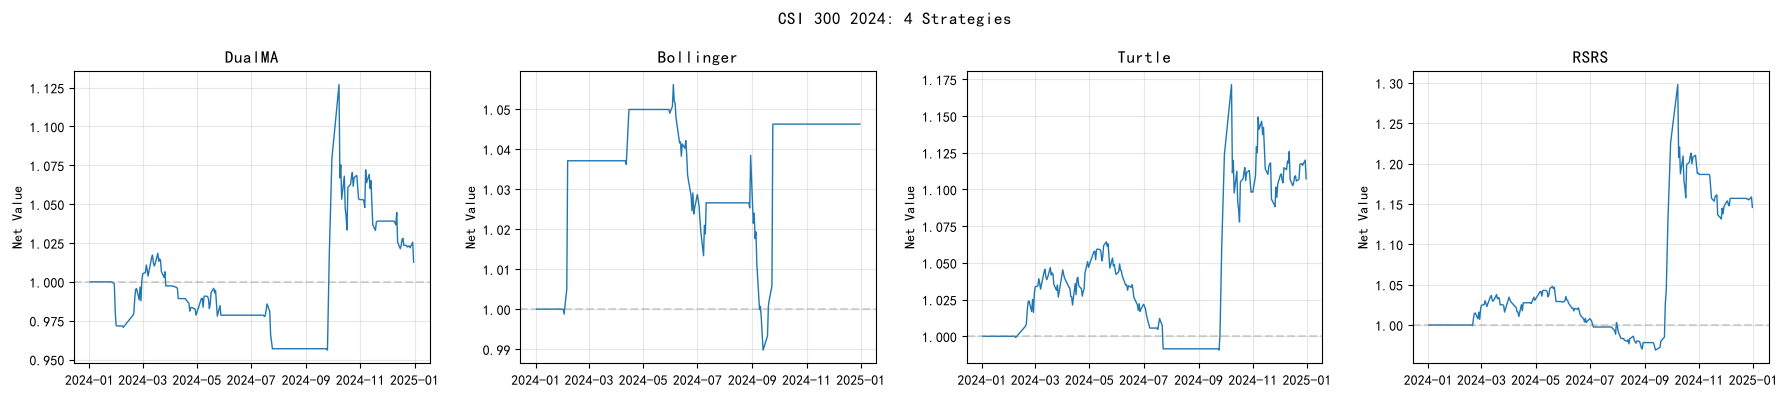

In [7]:
# 汇总对比
results = {}
for name, strat in [
    ("DualMA", DualMAStrategy(5, 20)),
    ("Bollinger", BollingerStrategy(20, 2.0)),
    ("Turtle", TurtleStrategy(20, 10, 20, 2.0)),
    ("RSRS", RSRSStrategy(18, 0.5, -0.5)),
]:
    eng = BacktestEngine(df_csi, strat, 1_000_000, 0.001, 0.0003)
    r = eng.run()
    results[name] = r

# 对比表
print(f"{'Strategy':12s} {'Return':>8s} {'Sharpe':>8s} {'MDD':>8s} {'Trades':>7s} {'WinRate':>8s}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:12s} {r.total_return*100:7.2f}% {r.sharpe_ratio:7.3f} "
          f"{r.max_drawdown*100:7.2f}% {r.total_trades:6d} {r.win_rate*100:7.1f}%")

# 策略相关性（用日收益序列）
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, r) in zip(axes, results.items()):
    navs = np.array([n for _, n in r.nav_history])
    ax.plot([t for t, _ in r.nav_history], navs / 1_000_000, lw=1)
    ax.set_title(f"{name}"); ax.axhline(y=1, color="gray", ls="--", alpha=0.3)
    ax.set_ylabel("Net Value"); ax.grid(True, alpha=0.3)
plt.suptitle("CSI 300 2024: 4 Strategies", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 8. 总结

### 你刚刚构建的

```
6 个策略 = 6 个 on_bar() 实现

双均线 → 布林带 → 海龟 → RSRS → 多因子 → 配对交易
  趋势        回归      系统     量价       截面      套利
```

### 策略设计原则

| 原则 | 说明 |
|------|------|
| 简单策略优先 | 参数越少 = 过拟合风险越低 |
| 先验逻辑 | 策略背后要有市场行为解释，不能纯数据挖掘 |
| 不同市场验证 | 一个策略在A股/加密都有效 → 更可信 |
| 别碰参数优化 | 调参让回测好看 = 自欺欺人。只有样本外验证才算数 |

### 下一步：风控与组合

单策略只是开始。真正的量化交易是**多策略组合**——低相关策略放在一起，分散的不只是股票，还有策略本身的失效风险。